In [1]:
import numpy as np

In [2]:
import sys
import os 

repo_path = "D:\\photoionization_analysis"
sys.path.append(repo_path)


from fortran_output_analysis.constants_and_parameters import g_eV_per_Hartree, fine_structure

g_omega_IR_eV = 1.55 # energy of IR photon used in simulations (in eV)
g_omega_IR_hart = (
    g_omega_IR_eV / g_eV_per_Hartree
)  # energy of IR photon used in simulations (in Hartree)

# nonrelativistic binding energy of the 4p orbital
nonrel_4p_bind_eV = 13.9996055
nonrel_4p_bind_hart = nonrel_4p_bind_eV / g_eV_per_Hartree

# cross-section constant, already contains conversion to Mbarn
au_to_Mbarn = 5.29177210903 ** 2
C_cs = 4 * np.pi / 3 * fine_structure * au_to_Mbarn
angstrom_to_eV = 2 * np.pi * 137.036 * 0.529177 * g_eV_per_Hartree

# charge of the ion
Z = 1

data_norel_abs = "D:\\Shake_ups\\nonrel_runs\\krypton\\no_su_6p_res_abs\\"
data_norel_emi = "D:\\Shake_ups\\nonrel_runs\\krypton\\no_su_6p_res_emi\\"
data_rel_abs = "D:\\Shake_ups\\relcode_runs\\krypton\\no_su_6p_res_abs\\output\\"
data_rel_emi = "D:\\Shake_ups\\relcode_runs\\krypton\\no_su_6p_res_emi\\output\\"

In [3]:
from fortran_output_analysis.nonrel.common_utility import Hole
from fortran_output_analysis.nonrel.onephoton.onephoton import Channels as Channels_1ph

l = "p"
hole = Hole("krypton", l, 4)
hole.load_binding_energy(data_norel_abs + "energies.dat")
print(f"bind energy [a.u]: {hole.binding_energy}")


data_files_abs = {
    "s": {
        "cs": data_norel_abs + "cross_4p_to_s.dat",
        "amp": data_norel_abs + "amplitude_ldown.dat",
        "phase": data_norel_abs + "phase_ldown.dat",
        },
    "d": {
        "cs": data_norel_abs + "cross_4p_to_d.dat",
        "amp": data_norel_abs + "amplitude_lup.dat",
        "phase": data_norel_abs + "phase_lup.dat",
        }
}

ch_1ph_abs = Channels_1ph(hole, data_files_abs, 3)

bind energy [a.u]: 0.5144760128515715


In [4]:
ch_1ph_abs.get_l_to_index(out_as="int")

{0: 0, 2: 1}

In [5]:
print(ch_1ph_abs.get_phase())
ch_1ph_abs.get_phase_one_channel("s")

[[-0.1996253 -0.1996405 -0.1996557 ... -0.2002027 -0.2002205 -0.2002383]
 [ 0.5557306  0.5557786  0.5558268 ...  0.5425312  0.5425911  0.5426508]]


array([-0.1996253, -0.1996405, -0.1996557, -0.199671 , -0.1996863,
       -0.1997017, -0.199717 , -0.1997325, -0.1997479, -0.1997634,
       -0.1997789, -0.1997945, -0.1998101, -0.1998257, -0.1998414,
       -0.1998571, -0.1998729, -0.1998886, -0.1999045, -0.1999203,
       -0.1999362, -0.1999522, -0.1999681, -0.1999842, -0.2000002,
       -0.2000163, -0.2000325, -0.2000486, -0.2000649, -0.2000811,
       -0.2000974, -0.2001138, -0.2001302, -0.2001466, -0.2001631,
       -0.2001796, -0.2001962, -0.2002128, -0.2002294, -0.2002461,
       -0.2002629, -0.2002797, -0.2002965, -0.2003134, -0.2003303,
       -0.2003473, -0.2003643, -0.2003814, -0.2003985, -0.2004157,
       -0.2004329, -0.2004502, -0.2004675, -0.2004849, -0.2005023,
       -0.2005198, -0.2005373, -0.2005549, -0.2005725, -0.2005902,
       -0.2006079, -0.2006257, -0.2006436, -0.2006615, -0.2006795,
       -0.2006975, -0.2007156, -0.2007337, -0.2007519, -0.2007701,
       -0.2007885, -0.2008068, -0.2008253, -0.2008437, -0.2008

In [6]:
import matplotlib.pyplot as plt

[-1725147.91110628+1.12591625e-08j  -674029.30056758+4.61053201e-09j
  -152543.549443  +1.34033757e-09j ...   152543.549443  -1.34031045e-09j
   674029.30056758-4.61066631e-09j  1725147.91110628-1.12593250e-08j]
Reload diagonal data in krypton!


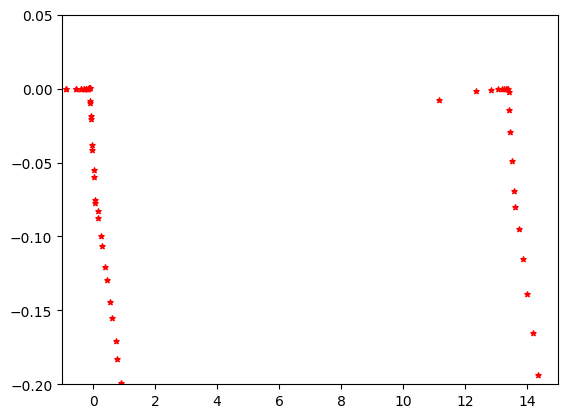

In [7]:
from fortran_output_analysis.nonrel.onephoton.onephoton import OnePhoton

krypton_1ph = OnePhoton("krypton")

krypton_1ph.load_diag_data(data_norel_abs, should_reload=True)
print(krypton_1ph.get_diag_eigenvalues())
krypton_1ph.load_diag_data(data_norel_abs, should_reload=True)

diag_eigvals = krypton_1ph.get_diag_eigenvalues()
diag_eigvals -= hole.binding_energy
diag_eigvals *= g_eV_per_Hartree

plt.scatter(np.real(diag_eigvals), np.imag(diag_eigvals),  marker="*", s=15, color="red", label="Nonrel.")
plt.xlim([-1, 15]);
plt.ylim([-0.2, 0.05]);

In [8]:
krypton_1ph_abs = OnePhoton("krypton")
krypton_1ph_emi = OnePhoton("krypton")

krypton_1ph_abs.load_hole(
    4,
    "p",
    data_norel_abs,
    bp_index=3,
    should_reload=True
)

krypton_1ph_emi.load_hole(
    4,
    "p",
    data_norel_emi,
    bp_index=3,
    should_reload=True
)

Text(0.5, 1.0, 'Phase, 1ph Emi')

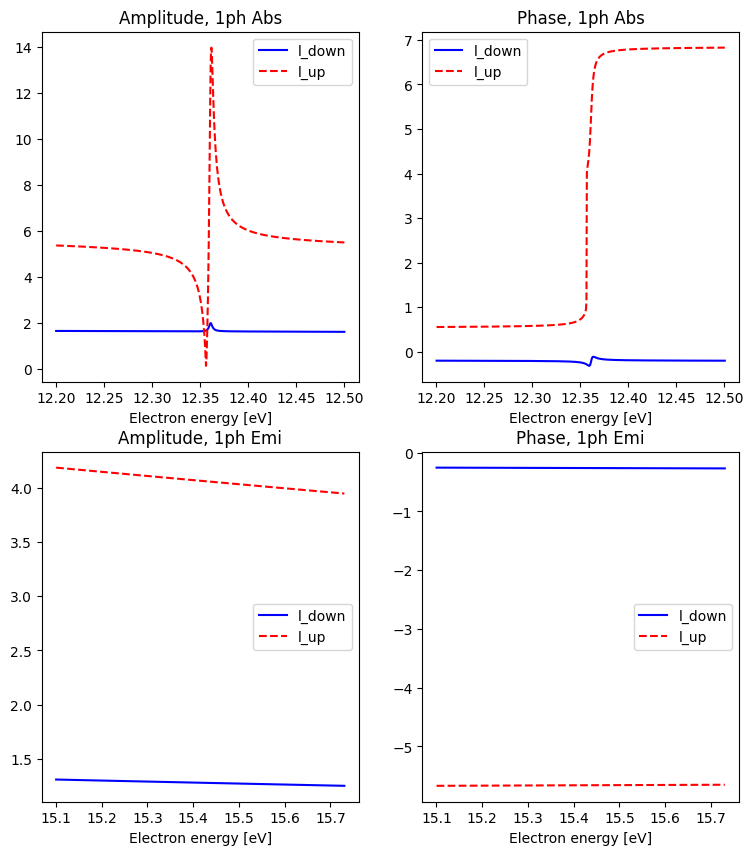

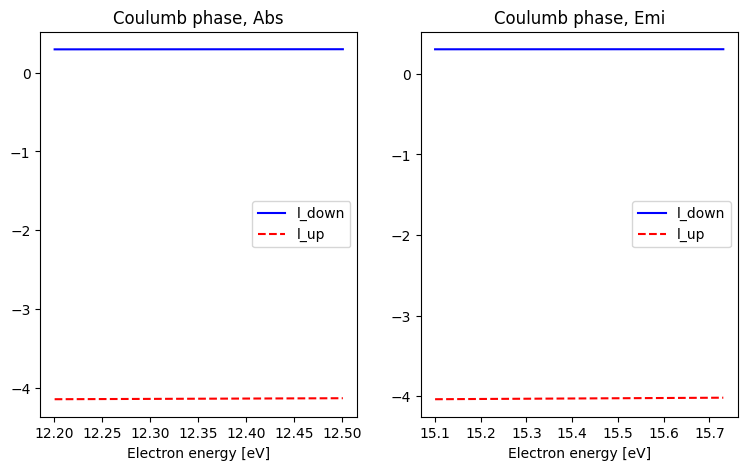

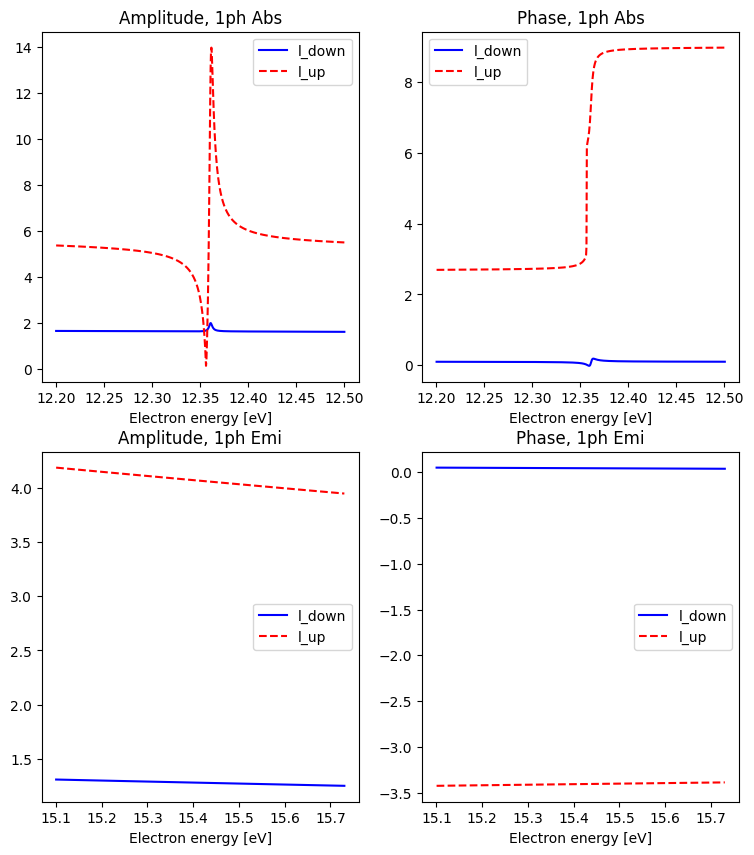

In [9]:
import fortran_output_analysis.nonrel.onephoton.utilities as utils_1ph

ekin_1ph_abs_eV = utils_1ph.get_ekin_eV(krypton_1ph_abs, 4, "p")
ekin_1ph_emi_eV = utils_1ph.get_ekin_eV(krypton_1ph_emi, 4, "p")
M_1ph_abs = utils_1ph.get_matrix_elements(krypton_1ph_abs, 4, "p")
M_1ph_emi = utils_1ph.get_matrix_elements(krypton_1ph_emi, 4, "p")

l_to_index_1ph = krypton_1ph_abs.get_channels_for_hole(4, "p").get_l_to_index(out_as="str")
s_idx = l_to_index_1ph["s"]
d_idx = l_to_index_1ph["d"]

plt.figure(figsize=(9, 10))
plt.subplot(2, 2, 1)
plt.plot(ekin_1ph_abs_eV, np.abs(M_1ph_abs[s_idx]), color="blue", label="l_down")
plt.plot(ekin_1ph_abs_eV, np.abs(M_1ph_abs[d_idx]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, 1ph Abs")

plt.subplot(2, 2, 2)
plt.plot(ekin_1ph_abs_eV, np.unwrap(np.angle(M_1ph_abs[s_idx])), color="blue", label="l_down")
plt.plot(ekin_1ph_abs_eV, np.unwrap(np.angle(M_1ph_abs[d_idx])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, 1ph Abs")

plt.subplot(2, 2, 3)
plt.plot(ekin_1ph_emi_eV, np.abs(M_1ph_emi[s_idx]), color="blue", label="l_down")
plt.plot(ekin_1ph_emi_eV, np.abs(M_1ph_emi[d_idx]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, 1ph Emi")

plt.subplot(2, 2, 4)
plt.plot(ekin_1ph_emi_eV, np.unwrap(np.angle(M_1ph_emi[s_idx])), color="blue", label="l_down")
plt.plot(ekin_1ph_emi_eV, np.unwrap(np.angle(M_1ph_emi[d_idx])) - 2 * np.pi, "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, 1ph Emi")


coul_phase_1ph_abs = utils_1ph.get_coulomb_phase(krypton_1ph_abs, 4, "p", Z)
coul_phase_1ph_emi = utils_1ph.get_coulomb_phase(krypton_1ph_emi, 4, "p", Z)

plt.figure(figsize=(9, 5))
plt.subplot(1, 2, 1)
plt.plot(ekin_1ph_abs_eV, coul_phase_1ph_abs[s_idx], color="blue", label="l_down")
plt.plot(ekin_1ph_abs_eV, coul_phase_1ph_abs[d_idx], "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Coulumb phase, Abs")

plt.subplot(1, 2, 2)
plt.plot(ekin_1ph_emi_eV, coul_phase_1ph_emi[s_idx], color="blue", label="l_down")
plt.plot(ekin_1ph_emi_eV, coul_phase_1ph_emi[d_idx], "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Coulumb phase, Emi")


# add Coulomb phase to the matrix elements
M_1ph_abs = utils_1ph.get_matrix_elements_with_coulomb_phase(krypton_1ph_abs, 4, "p", Z)
M_1ph_emi = utils_1ph.get_matrix_elements_with_coulomb_phase(krypton_1ph_emi, 4, "p", Z)
plt.figure(figsize=(9, 10))
plt.subplot(2, 2, 1)
plt.plot(ekin_1ph_abs_eV, np.abs(M_1ph_abs[s_idx]), color="blue", label="l_down")
plt.plot(ekin_1ph_abs_eV, np.abs(M_1ph_abs[d_idx]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, 1ph Abs")

plt.subplot(2, 2, 2)
plt.plot(ekin_1ph_abs_eV, np.unwrap(np.angle(M_1ph_abs[s_idx])), color="blue", label="l_down")
plt.plot(ekin_1ph_abs_eV, np.unwrap(np.angle(M_1ph_abs[d_idx])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, 1ph Abs")

plt.subplot(2, 2, 3)
plt.plot(ekin_1ph_emi_eV, np.abs(M_1ph_emi[s_idx]), color="blue", label="l_down")
plt.plot(ekin_1ph_emi_eV, np.abs(M_1ph_emi[d_idx]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, 1ph Emi")

plt.subplot(2, 2, 4)
plt.plot(ekin_1ph_emi_eV, np.unwrap(np.angle(M_1ph_emi[s_idx])), color="blue", label="l_down")
plt.plot(ekin_1ph_emi_eV, np.unwrap(np.angle(M_1ph_emi[d_idx])) - 2 * np.pi, "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, 1ph Emi")

Text(0.5, 1.0, 'Phase, upper harm')

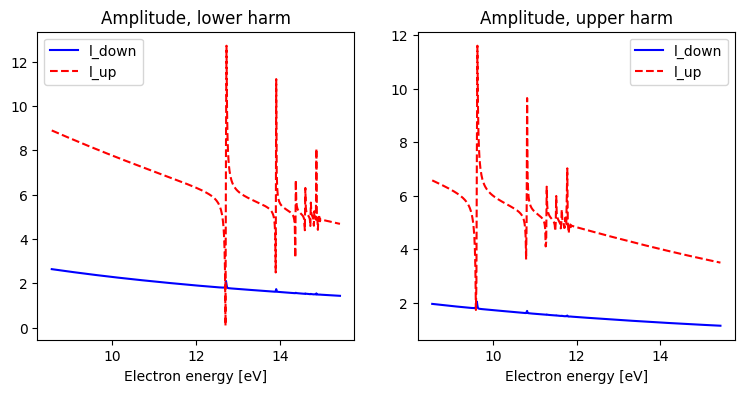

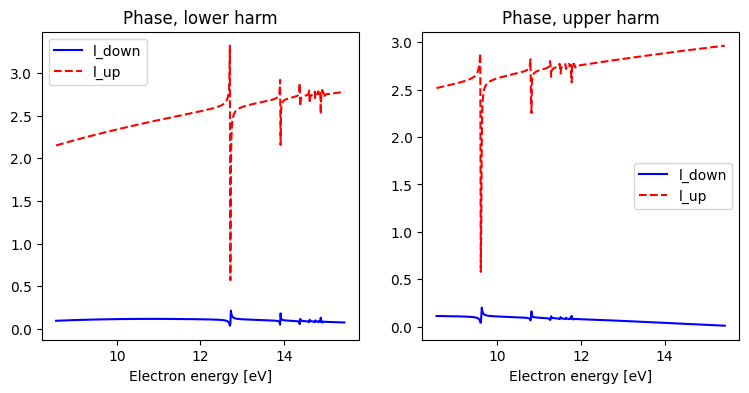

In [10]:
data_nonrel_1sim = "D:\\Shake_ups\\nonrel_runs\\krypton\\no_su_21_31\\"

krypton_1ph_1sim = OnePhoton("krypton")
krypton_1ph_1sim.load_hole(4, "p", data_nonrel_1sim)


en_final_1sim, M_emi_matched_1sim, M_abs_matched_1sim = utils_1ph.prepare_matrices_1sim(
                                                                    krypton_1ph_1sim,
                                                                    4,
                                                                    "p",
                                                                    Z,
                                                                    g_omega_IR_hart,
                                                                    "abs"
                                                                    )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final_1sim, np.abs( M_abs_matched_1sim[0]), color="blue", label="l_down")
plt.plot(en_final_1sim, np.abs( M_abs_matched_1sim[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final_1sim, np.abs(M_emi_matched_1sim[0]), color="blue", label="l_down")
plt.plot(en_final_1sim, np.abs(M_emi_matched_1sim[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, upper harm")


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final_1sim,  np.unwrap(np.angle(M_abs_matched_1sim[0])), color="blue", label="l_down")
plt.plot(en_final_1sim,  np.unwrap(np.angle(M_abs_matched_1sim[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final_1sim,  np.unwrap(np.angle(M_emi_matched_1sim[0])), color="blue", label="l_down")
plt.plot(en_final_1sim,  np.unwrap(np.angle(M_emi_matched_1sim[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, upper harm")

Text(0.5, 1.0, 'Phase')

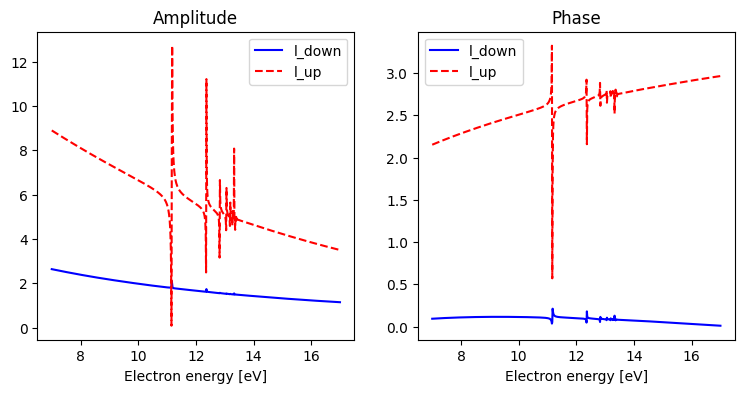

In [11]:
ekin_1ph_1sim_eV = utils_1ph.get_ekin_eV(krypton_1ph_1sim, 4, "p")

M = utils_1ph.get_matrix_elements_with_coulomb_phase(
            krypton_1ph_1sim,
            4,
            "p",
            Z,
            )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(ekin_1ph_1sim_eV , np.abs( M[0]), color="blue", label="l_down")
plt.plot(ekin_1ph_1sim_eV , np.abs( M[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(ekin_1ph_1sim_eV ,  np.unwrap(np.angle(M[0])), color="blue", label="l_down")
plt.plot(ekin_1ph_1sim_eV ,  np.unwrap(np.angle(M[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase")

Text(0.5, 1.0, 'Phase, upper harm')

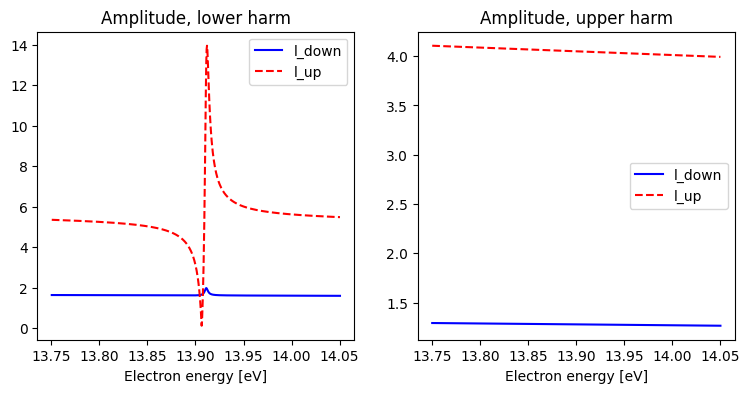

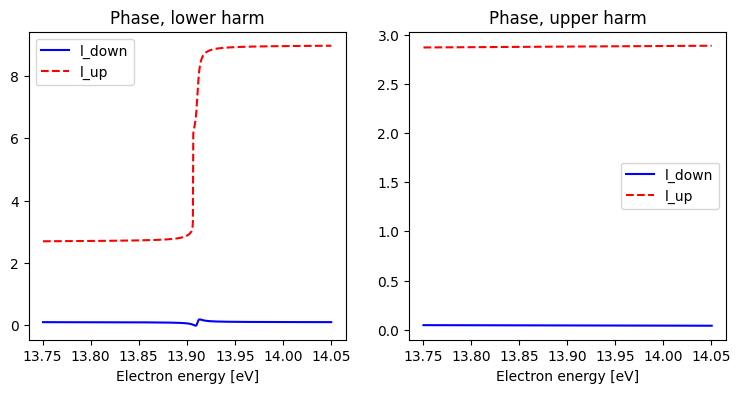

In [12]:
en_final, M_emi_matched, M_abs_matched = utils_1ph.prepare_matrices_2sim(
                                                    krypton_1ph_emi,
                                                    krypton_1ph_abs,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    g_omega_IR_hart,
                                                    "abs",
                                                    "interp_both"
                                                    )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.abs(M_abs_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_abs_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.abs(M_emi_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_emi_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, upper harm")


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[0])), color="blue", label="l_down")
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.angle(M_emi_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.angle(M_emi_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, upper harm")

Text(0.5, 1.0, 'Phase, upper harm')

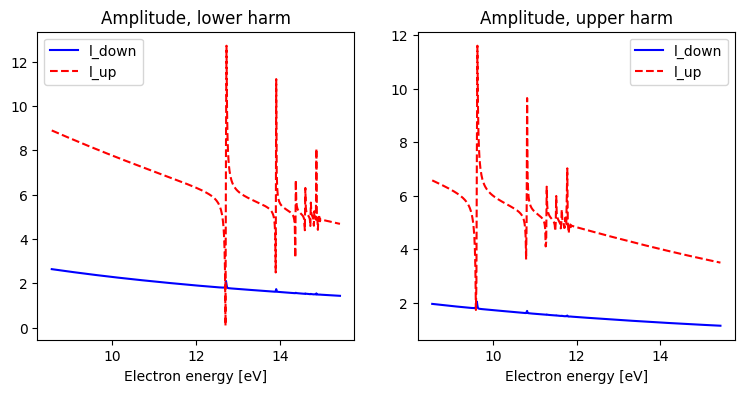

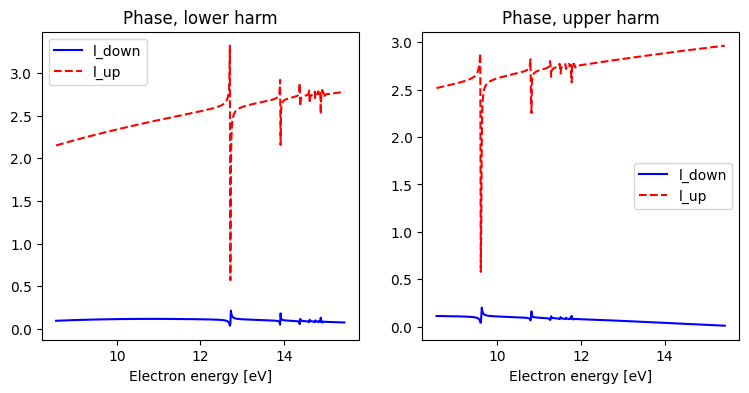

In [13]:
en_final, M_emi_matched, M_abs_matched = utils_1ph.get_prepared_matrices(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",                                                    
                                                    )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.abs(M_abs_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_abs_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.abs(M_emi_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_emi_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, upper harm")


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[0])), color="blue", label="l_down")
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.unwrap(np.angle(M_emi_matched[0])), color="blue", label="l_down")
plt.plot(en_final, np.unwrap(np.angle(M_emi_matched[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, upper harm")

Text(0.5, 1.0, 'Phase, upper harm')

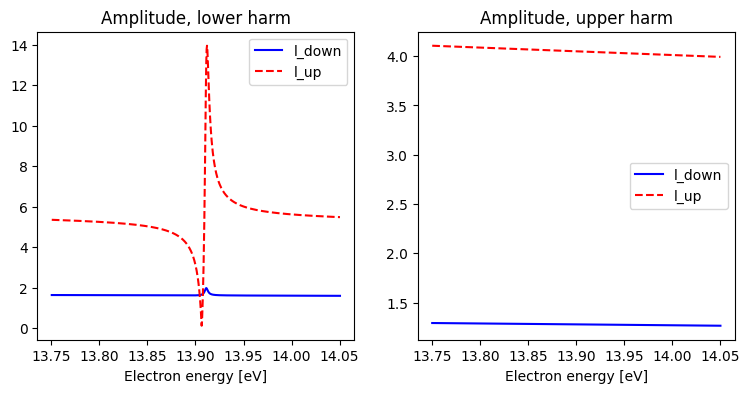

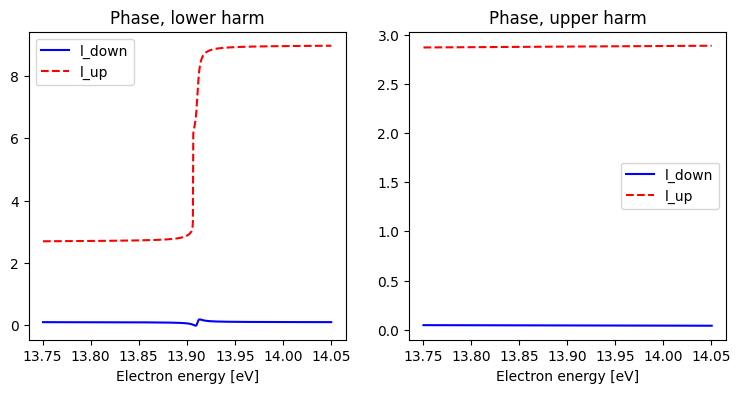

In [14]:
en_final, M_emi_matched, M_abs_matched = utils_1ph.get_prepared_matrices(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both"
                                                    )


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.abs(M_abs_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_abs_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.abs(M_emi_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.abs(M_emi_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Amplitude, upper harm")


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[0])), color="blue", label="l_down")
plt.plot(en_final, np.unwrap(np.angle(M_abs_matched[1])), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, lower harm")

plt.subplot(1, 2, 2)
plt.plot(en_final, np.angle(M_emi_matched[0]), color="blue", label="l_down")
plt.plot(en_final, np.angle(M_emi_matched[1]), "--", color="red", label="l_up")
plt.legend()
plt.xlabel("Electron energy [eV]")
plt.title("Phase, upper harm")

In [15]:
import fortran_output_analysis.nonrel.onephoton.cross_section as cross_sec

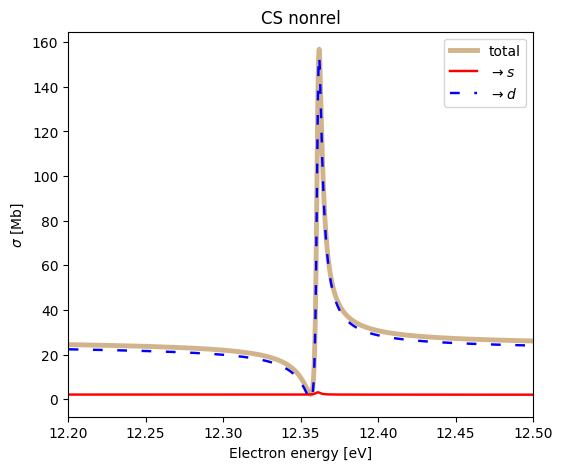

In [16]:
en, cs_s = cross_sec.get_integrated_photoion_cs_for_channel(krypton_1ph_abs, 4, "p", "s")
en, cs_d = cross_sec.get_integrated_photoion_cs_for_channel(krypton_1ph_abs, 4, "p", "d")
en, cs_tot = cross_sec.get_integrated_photoion_cs(krypton_1ph_abs, 4, "p")

plt.figure("CS nonrel.", figsize=(6, 5))
plt.plot(en, cs_tot, linewidth=3.5, color="tan", label="total");
plt.plot(en, cs_s, "-", linewidth=1.75, color="red", label="$\\to s$");
plt.plot(en, cs_d, linestyle=(20, (4, 6)), linewidth=1.75, color="blue", label="$\\to d$");
plt.title("CS nonrel");
plt.xlim([12.2, 12.5]);
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\sigma$ [Mb]");
plt.legend();

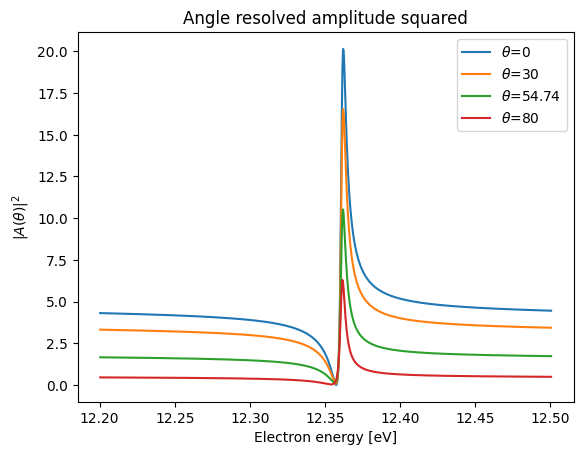

In [17]:
angles = [0, 30, 54.74, 80]
en, amp_sq_ang = cross_sec.get_ang_resolved_amplitude_squared(krypton_1ph_abs, 4, "p", Z, angles)

plt.figure()
for i in range(len(angles)):
    plt.plot(en, amp_sq_ang[i], label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|A(\\theta)|^2$");
plt.legend();
plt.title("Angle resolved amplitude squared");


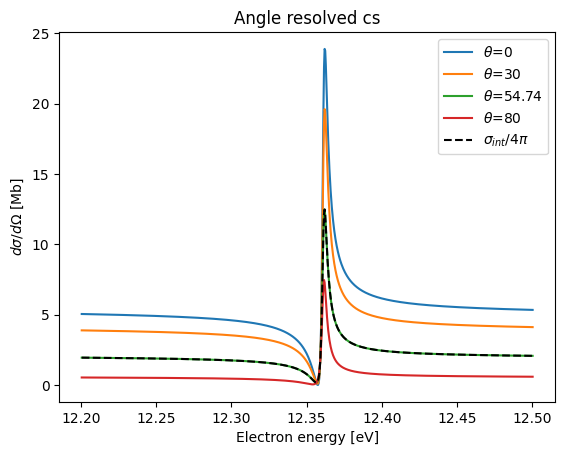

In [18]:
angles = [0, 30, 54.74, 80]
en, cs_ang = cross_sec.get_ang_resolved_photoion_cs(krypton_1ph_abs, 4, "p", Z, angles)

plt.figure()
for i in range(len(angles)):
    plt.plot(en, cs_ang[i], label=f"$\\theta$={angles[i]}")

plt.plot(en, cs_tot / (4 * np.pi), "--", color="black", linewidth=1.5, label="$\\sigma_{int} / 4 \\pi$")
plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$d\\sigma / d\\Omega$ [Mb]");
plt.legend();
plt.title("Angle resolved cs");


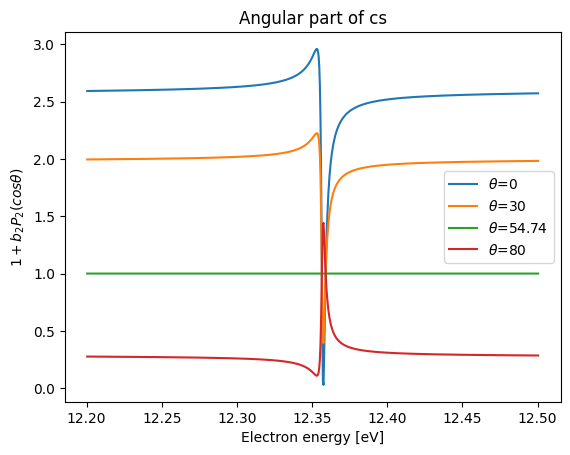

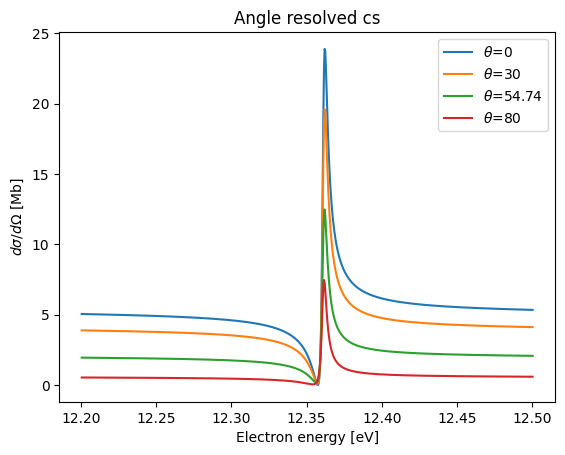

In [19]:
angles = [0, 30, 54.74, 80]
en, ang_part = cross_sec.get_ang_part_of_photoion_cs(krypton_1ph_abs, 4, "p", Z, angles)

plt.figure()
for i in range(len(angles)):
    plt.plot(en, ang_part[i], label=f"$\\theta$={angles[i]}")
plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$1 + b_2 P_2(cos \\theta)$");
plt.legend();
plt.title("Angular part of cs");


# check if we get back the ang resolved cs

plt.figure()
for i in range(len(angles)):
    plt.plot(en, ang_part[i] * cs_tot / (4 * np.pi), label=f"$\\theta$={angles[i]}")
plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$d\\sigma / d\\Omega$ [Mb]");
plt.legend();
plt.title("Angle resolved cs");

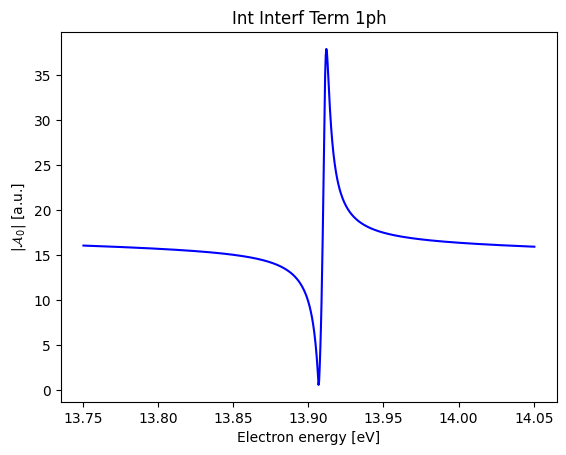

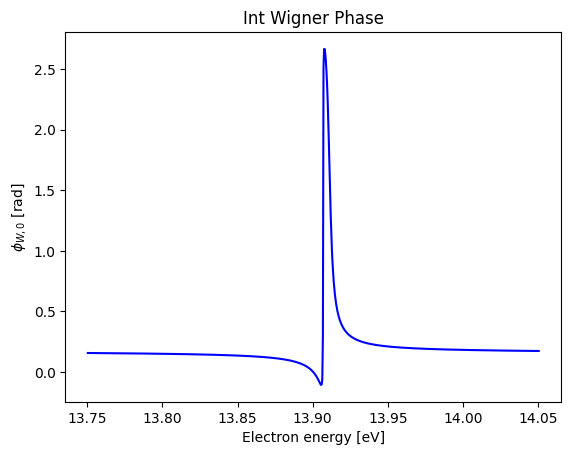

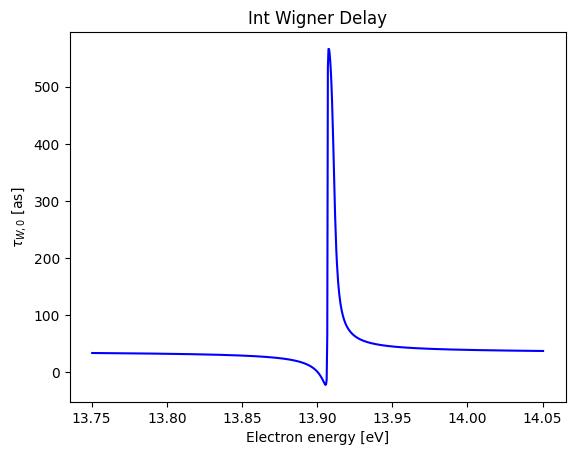

In [20]:
import fortran_output_analysis.nonrel.onephoton.delays_and_phases as wigner

from fortran_output_analysis.common_utility import delay_to_phase


ekin_final, interf_term_1ph_int = wigner.get_integrated_sb_intefer_term(                                                    
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                )

_, wigner_phase_int = wigner.get_integrated_wigner_phase(                                                    
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True
                                                )

_, wigner_delay_int = wigner.get_integrated_wigner_delay(                                                    
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True
                                                )


plt.figure()
plt.plot(ekin_final, np.abs(interf_term_1ph_int), color="blue")
plt.title("Int Interf Term 1ph");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|\\mathcal{A}_{0}|$ [a.u.]");

plt.figure()
plt.plot(ekin_final, wigner_phase_int, color="blue")
plt.title("Int Wigner Phase");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\phi_{W, 0}$ [rad]");

plt.figure()
plt.plot(ekin_final, wigner_delay_int, color="blue")
plt.title("Int Wigner Delay");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\tau_{W, 0}$ [as]");

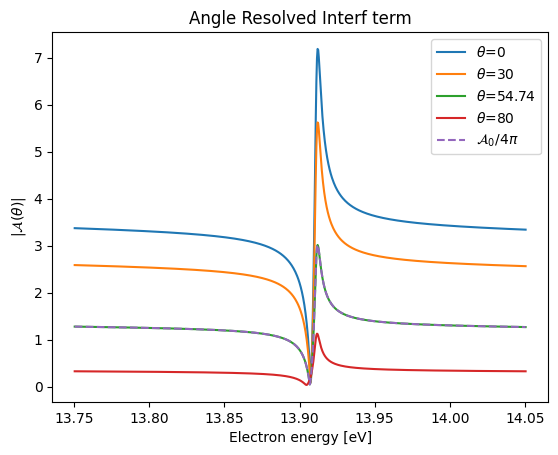

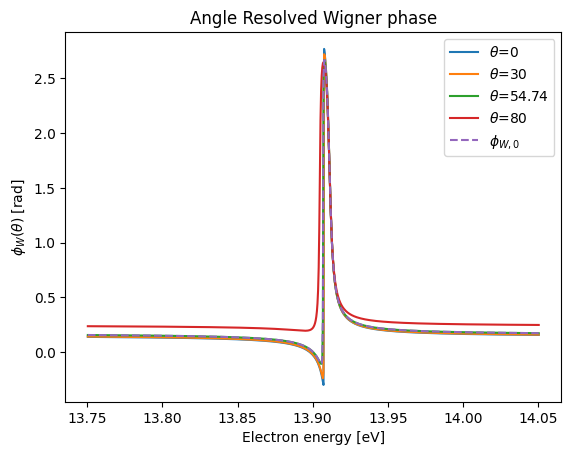

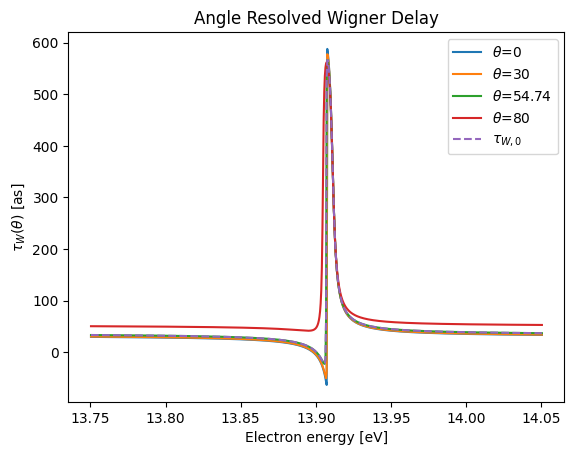

In [21]:
angles = [0, 30, 54.74, 80]
ekin_final, interf_term_1ph_ang = wigner.get_ang_resolved_sb_interf_term(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                )

ekin_final, wigner_phase_ang = wigner.get_ang_resolved_wigner_phase(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True,
                                                )


ekin_final, wigner_delay_ang = wigner.get_ang_resolved_wigner_delay(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True,
                                                )

plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, np.abs(interf_term_1ph_ang[i]), label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, np.abs(interf_term_1ph_int) / (4 * np.pi), "--", label="$\\mathcal{A}_0 / 4 \\pi$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|\\mathcal{A}(\\theta)|$");
plt.legend();
plt.title("Angle Resolved Interf term");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_phase_ang[i], label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, wigner_phase_int , "--", label="$\\phi_{W,0}$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\phi_W(\\theta)$ [rad]");
plt.legend();
plt.title("Angle Resolved Wigner phase");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_delay_ang[i], label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, wigner_delay_int, "--", label="$\\tau_{W,0}$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\tau_W(\\theta)$ [as]");
plt.legend();
plt.title("Angle Resolved Wigner Delay");

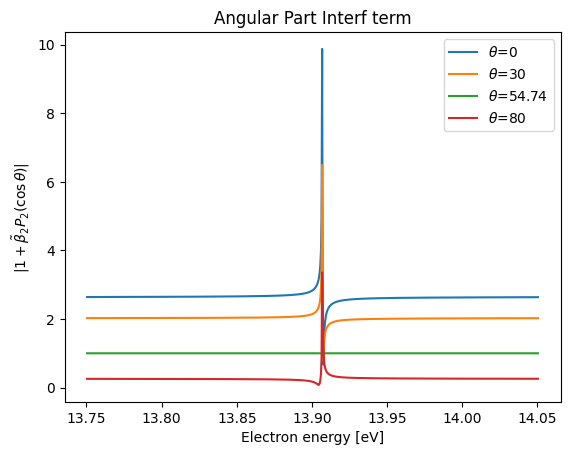

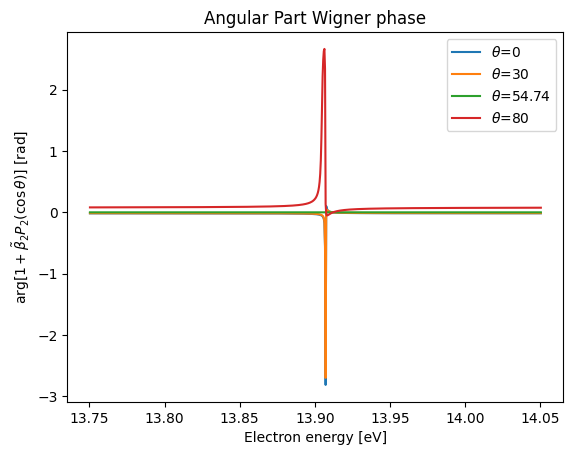

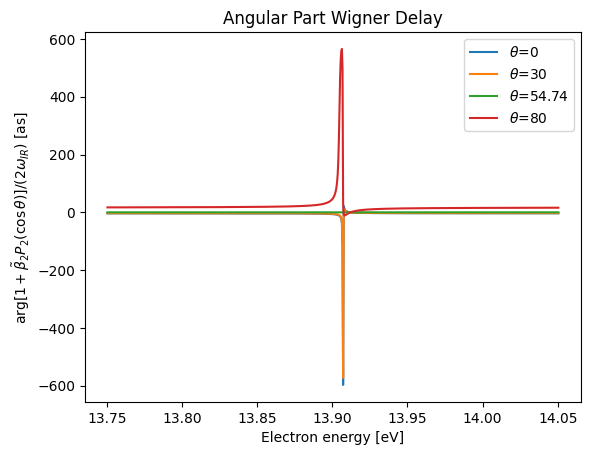

In [22]:
angles = [0, 30, 54.74, 80]
ekin_final, interf_term_1ph_ang_part = wigner.get_ang_part_of_sb_interf_term(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                )

ekin_final, wigner_phase_ang_part = wigner.get_ang_part_of_wigner_phase(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True,
                                                )


ekin_final, wigner_delay_ang_part = wigner.get_ang_part_of_wigner_delay(
                                                    krypton_1ph_emi,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    one_photon_2=krypton_1ph_abs,
                                                    g_omega_IR_hart_2=g_omega_IR_hart,
                                                    match_mode="interp_both",
                                                    unwrap=True,
                                                )

plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, np.abs(interf_term_1ph_ang_part[i]), label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)|$");
plt.legend();
plt.title("Angular Part Interf term");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_phase_ang_part[i], label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\arg[1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)]$ [rad]");
plt.legend();
plt.title("Angular Part Wigner phase");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_delay_ang_part[i], label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\arg[1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)] / (2 \\omega_{IR})$ [as]");
plt.legend();
plt.title("Angular Part Wigner Delay");

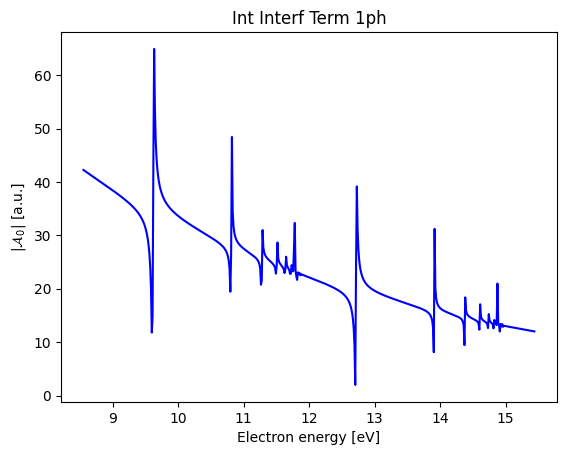

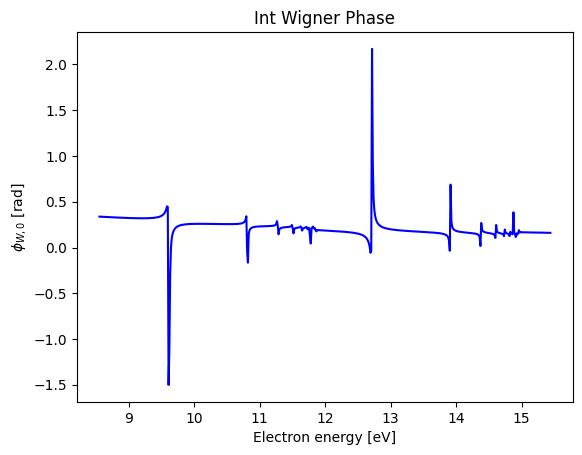

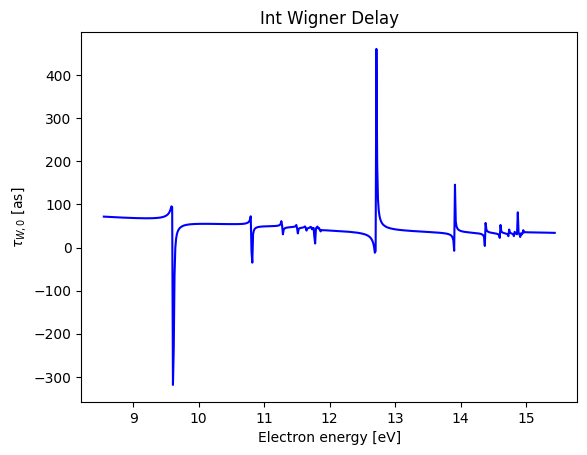

In [23]:
ekin_final, interf_term_1ph_1sim_int = wigner.get_integrated_sb_intefer_term(                                                    
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                )

_, wigner_phase_1sim_int = wigner.get_integrated_wigner_phase(                                                    
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    unwrap=True
                                                )

_, wigner_delay_1sim_int = wigner.get_integrated_wigner_delay(                                                    
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    unwrap=True
                                                )


plt.figure()
plt.plot(ekin_final, np.abs(interf_term_1ph_1sim_int), color="blue")
plt.title("Int Interf Term 1ph");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|\\mathcal{A}_{0}|$ [a.u.]");

plt.figure()
plt.plot(ekin_final, wigner_phase_1sim_int, color="blue")
plt.title("Int Wigner Phase");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\phi_{W, 0}$ [rad]");

plt.figure()
plt.plot(ekin_final, wigner_delay_1sim_int, color="blue")
plt.title("Int Wigner Delay");
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\tau_{W, 0}$ [as]");

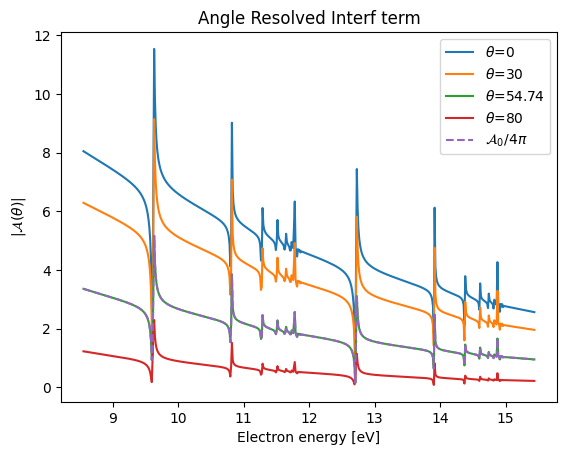

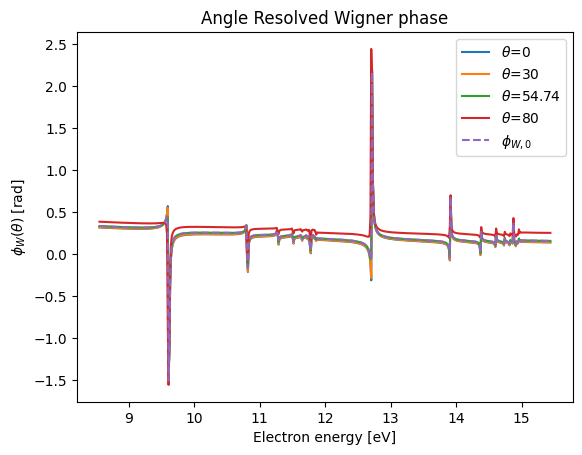

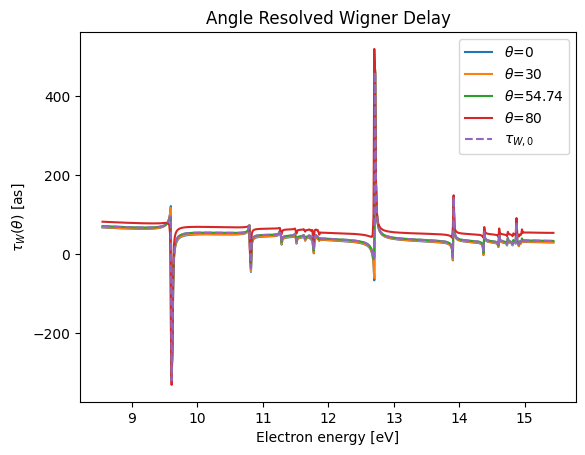

In [24]:
angles = [0, 30, 54.74, 80]
ekin_final, interf_term_1ph_1sim_ang = wigner.get_ang_resolved_sb_interf_term(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles
                                                )

ekin_final, wigner_phase_1sim_ang = wigner.get_ang_resolved_wigner_phase(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    unwrap=True,
                                                )


ekin_final, wigner_delay_1sim_ang = wigner.get_ang_resolved_wigner_delay(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    unwrap=True,
                                                )

plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, np.abs(interf_term_1ph_1sim_ang[i]), label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, np.abs(interf_term_1ph_1sim_int) / (4 * np.pi), "--", label="$\\mathcal{A}_0 / 4 \\pi$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|\\mathcal{A}(\\theta)|$");
plt.legend();
plt.title("Angle Resolved Interf term");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_phase_1sim_ang[i], label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, wigner_phase_1sim_int , "--", label="$\\phi_{W,0}$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\phi_W(\\theta)$ [rad]");
plt.legend();
plt.title("Angle Resolved Wigner phase");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_delay_1sim_ang[i], label=f"$\\theta$={angles[i]}")
plt.plot(ekin_final, wigner_delay_1sim_int, "--", label="$\\tau_{W,0}$")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\tau_W(\\theta)$ [as]");
plt.legend();
plt.title("Angle Resolved Wigner Delay");

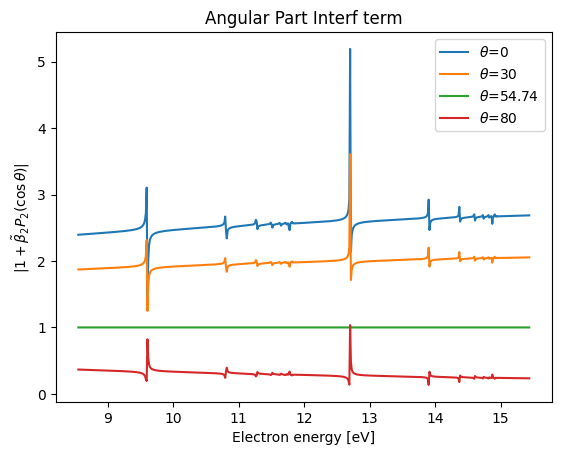

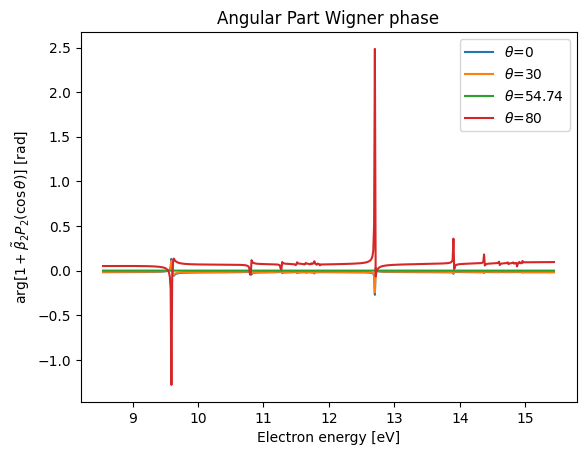

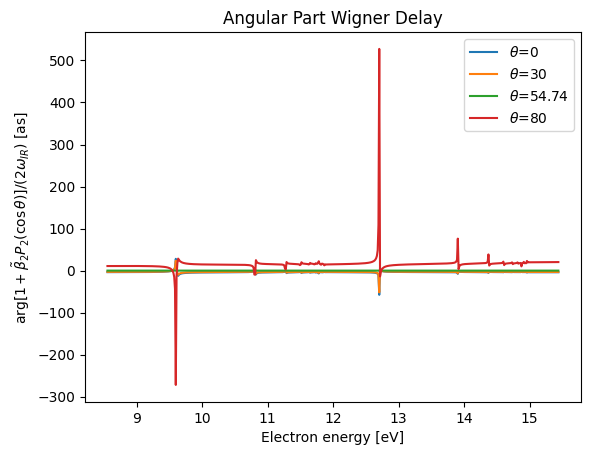

In [25]:
angles = [0, 30, 54.74, 80]
ekin_final, interf_term_1ph_1sim_ang_part = wigner.get_ang_part_of_sb_interf_term(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles
                                                )
                                    

ekin_final, wigner_phase_1sim_ang_part = wigner.get_ang_part_of_wigner_phase(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    unwrap=True,
                                                )


ekin_final, wigner_delay_1sim_ang_part = wigner.get_ang_part_of_wigner_delay(
                                                    krypton_1ph_1sim,
                                                    4,
                                                    "p",
                                                    Z,
                                                    g_omega_IR_hart,
                                                    energies_mode="abs",
                                                    angles_deg=angles,
                                                    unwrap=True,
                                                )

plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, np.abs(interf_term_1ph_1sim_ang_part[i]), label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$|1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)|$");
plt.legend();
plt.title("Angular Part Interf term");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_phase_1sim_ang_part[i], label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\arg[1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)]$ [rad]");
plt.legend();
plt.title("Angular Part Wigner phase");


plt.figure()
for i in range(len(angles)):
    plt.plot(ekin_final, wigner_delay_1sim_ang_part[i], label=f"$\\theta$={angles[i]}")

plt.legend()
plt.xlabel("Electron energy [eV]");
plt.ylabel("$\\arg[1 + \\tilde{\\beta}_2 P_2(\\cos \\theta)] / (2 \\omega_{IR})$ [as]");
plt.legend();
plt.title("Angular Part Wigner Delay");